In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

'\nWe will use synthetic data to train the linear regression model. We’ll initialize a variable X with values from −5 to 5 and create a linear function that has a slope of −5. Note that this function will be estimated by our trained model later.\n'

In [ ]:
'''
We will use synthetic data to train the linear regression model. We’ll initialize a variable X with values from −5 to 5 and create a linear function that has a slope of −5. Note that this function will be estimated by our trained model later.
'''


# Creating a function f(X) with a slope of -5

# arange : Similar to Python’s built-in range(), but for tensors and with decimals allowed.
# view : view(rows, columns), -1 means auto calculate no of rows
X = torch.arange(-5, 5, 0.1).view(-1, 1)
func = -5 * X 

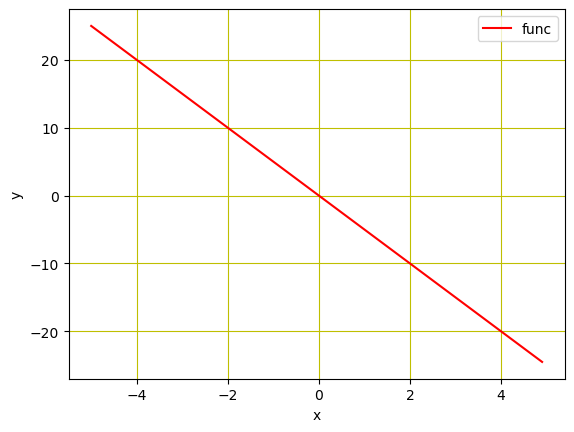

In [3]:
# Plot the line in red with grids
plt.plot(X.numpy(), func.numpy(), 'r', label='func')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid('True', color='y')
plt.show()

In [6]:
""" 
As we need to simulate the real data we just created, let’s add some Gaussian noise to it in order to create noisy data, keeping the value of standard deviation 0.4
"""

# Adding Gaussian noise to the function f(X) and saving it in Y
Y = func + 0.4 * torch.randn(X.size())

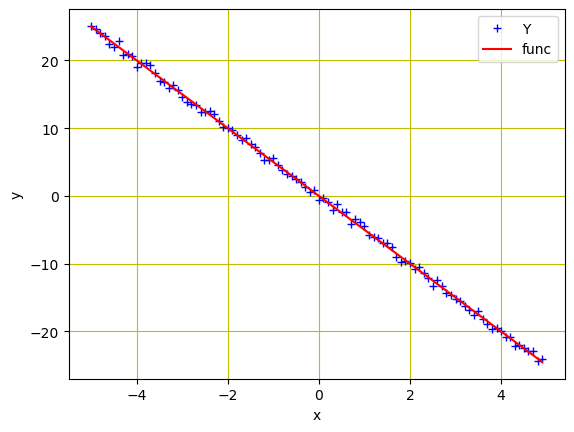

In [7]:
#Now, let’s visualize these data points using below lines of code.

plt.plot(X.numpy(), Y.numpy(), 'b+', label='Y')
plt.plot(X.numpy(), func.numpy(), 'r', label='func')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid('True', color='y')
plt.show()

In [ ]:
# With all these preparations, we are ready for model training. First, the parameter 𝑤 need to be initialized randomly, for example, to the value −10.
w = torch.tensor(-10.0, requires_grad=True)

# defining the function for forward pass for prediction
def forward(x):
    return w * x


In [ ]:
# In training steps, we’ll need a criterion to measure the loss between the original and the predicted data points. 

# evaluating data points with Mean Square Error.
# L(y1​,y2​)=(y1​−y2​)^2
# average loss across the whole training set (the empirical risk)
def criterion(y_pred, y):
    return torch.mean((y_pred - y) ** 2)

In [ ]:
# Next, we’ll define the learning rate or the step size, an empty list to store the loss after each iteration, and the number of iterations we want our model to train for. While the step size is set at 0.1, we train the model for 20 iterations per epochs.

step_size = 0.1
loss_list = []
iter = 20

In [17]:
''' 
When below lines of code is executed, the forward() function takes an input and generates a prediction. 
The criterian() function calculates the loss and stores it in loss variable.
Based on the model loss, the backward() method computes the gradients and w.data stores the updated parameters.
 ''' 



''' 
    Through Understnading, on what's going on with loss:

    loss gives us 2 different values where d is partial derivative d loss / d weight and d loss / d bias, this gives you the direction where the slop can be reduced from the position you are standing at. 
    When you know where you are standing at ,and you know the direction to go towrds maximum distance , then you can negate that to know the direction towards minimum value. 
    In the next pass we do exactly that. 

    # to move in a particular direciton we'd require, magnitue (how far we want to move) and the direction itself. 

    w(new) = w(old) - direction we want to move
    w(new) = w(old) - learning_rate * w.grad.data 

    learning_rate --> how far you'd want to move 
    w.grad.data --> this gives you the direction of maximum ascent and we negate this value to move in the direciton of maximum descent 
 '''

for i in range (iter):
    # making predictions with forward pass
    Y_pred = forward(X)
    # calculating the loss between original and predicted data points
    loss = criterion(Y_pred, Y)
    # storing the calculated loss in a list
    loss_list.append(loss.item())
    # backward pass for computing the gradients of the loss w.r.t to learnable parameters

    loss.backward()
    # updateing the parameters after each iteration
    w.data = w.data - step_size * w.grad.data
    # zeroing gradients after each iteration
    w.grad.data.zero_()
    # priting the values for understanding
    print('{},\t{},\t{}'.format(i, loss.item(), w.item()))

0,	0.17584094405174255,	-4.997925758361816
1,	0.17583034932613373,	-4.999614715576172
2,	0.17582553625106812,	-4.998488426208496
3,	0.1758234202861786,	-4.999239444732666
4,	0.17582246661186218,	-4.998738765716553
5,	0.17582207918167114,	-4.999072551727295
6,	0.17582187056541443,	-4.998849868774414
7,	0.17582184076309204,	-4.998998641967773
8,	0.17582176625728607,	-4.998898983001709
9,	0.17582176625728607,	-4.998965740203857
10,	0.1758217215538025,	-4.998920917510986
11,	0.17582173645496368,	-4.998950958251953
12,	0.1758217215538025,	-4.998930931091309
13,	0.1758217215538025,	-4.998944282531738
14,	0.17582173645496368,	-4.998935222625732
15,	0.1758216917514801,	-4.998941421508789
16,	0.17582176625728607,	-4.998937129974365
17,	0.17582173645496368,	-4.998940467834473
18,	0.1758217215538025,	-4.998938083648682
19,	0.17582173645496368,	-4.998939514160156


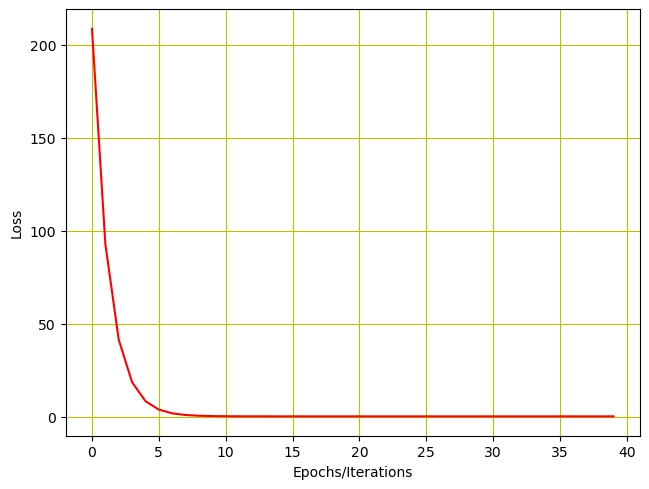

In [18]:
# Plotting the loss after each iteration, loss is stored in loss_list we simply use that
plt.plot(loss_list, 'r')
plt.tight_layout()
plt.grid('True', color='y')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.show()